# Notebook 3 - Debye model and theory of spectral functions

As observed in the previous notebook, there are three major effects of irradiation on the VDOS of graphite:
- (1) VDOS of the disordered system is smoother compared with the crystalline reference
- (2) peaks of the VDOS in the disordered system are shifted compared to the VDOS of the crystalline reference
- (3) lower normalization of the VDOS of the disordered system compared with crystalline reference

Here, we will show that these effects can be attributed to two physical causes:
1) change in the density caused by irradiation leads to frequency shifts and VDOS renormalization
2) disorder caused by irradiation will lead to broadening, and eventual inability to define bands. This can be associated to phonon scattering caused by disorder, which will broaden phonon spectral functions and cause VDOS to become more smooth.


We will explore these effects in this notebook looking at an example of Debye density of states.

## Debye model derivation
First we derive the Debye density of states from scratch, starting from idea of waves in a cubic box, then assuming linear dispersion relation and transforming to spherical coordinates ignoring cubic limits of the maximum wavevectors.

Within periodic solids, we know from Bloch theorem that the wavefunctions of the form $\psi = e^{iqr} U(r)$ will be solutions to the system's Hamiltonian.
Within 3D system, with periodic boundary conditions in x, y, z the possible values of $q$ will be $q \in [n, m, l] * \frac{1}{N_L} \frac{2\pi}{a}$ ($a$ is the bond distance, assumed cell is cubic with size $L = N_L a$), unique values of n,m, l are $[0, ..., N_L -1]$

The number of possible $q$-points within some volume of the Brillouin zone can be estimated from the volume per $q$-point:

volume per point: $V_{\rm point} = \frac{(2 \pi)^3}{(N_L a)^3} = \frac{(2 \pi)^3}{\mathcal{V}}$, volume of the Brillouin zone: $V_{\rm BZ} = \frac{(2 \pi)^3}{a^3} = \frac{(2 \pi)^3}{V_{\rm at}}$

The number density of the material: $\rho_n = \frac{1}{V_{\rm at}}$

The total number of atoms is $N = N_L^3 = \frac{V_{\rm BZ}}{V_{\rm point} }$

We can also write the number of possible $q$-points as integration across the BZ ($q_{\rm max} = 2 \pi / a$):
$$ \int_0^{q_{\rm max}} \int_0^{q_{\rm max}} \int_0^{q_{\rm max}} dq_x dq_y dq_z * \frac{1}{V_{\rm point}} = N $$


Now, assume linear dispersion relation $\omega = c q$, and ignore the cubic form of the integral, evaluate the integral in spherical coordinates with a single cutoff $q_{\rm cutoff}$ and substitute for $V_{\rm point}$:

$$ N = \int_0^{q_{\rm cutoff}} dq 4 \pi q^2 * \frac{\mathcal{V}}{(2 \pi)^3 } $$

Substitute for $\omega$ and take system's volume $\mathcal{V}$ to the other side:

$$ N / \mathcal{V} = \rho_n = \int_0^{q_{\rm cutoff}} dq 4 \pi q^2 * \frac{1}{(2 \pi)^3 } = \int_0^{\omega_{\rm cutoff}} d\omega \omega^2  \frac{1}{2 \pi^2 c^3 }$$

Finally the amount of states in 3D systems is 3 times the number of possible $q$-points due to 3 possible polarizations (which corresponds to 3 degrees of freedom per atom). So multiplying the equation by 3, we get:

$$ 3 \rho_n = \int_0^{\omega_{\rm cutoff}} d\omega \omega^2  \frac{3}{2 \pi^2 c^3 } = \int_0^{\omega_{\rm cutoff}} d\omega g(\omega)$$
where $g(\omega) = \omega^2  \frac{3}{2 \pi^2 c^3 }$. We can obtain the cutoff by integrating through:

$$\rho_n = \int_0^{\omega_{\rm cutoff}} d\omega \omega^2  \frac{1}{2 \pi^2 c^3 }  = \frac{1}{2 \pi^2 c^3 } \frac{\omega^3_{\rm cutoff}}{3}$$

Hence $\omega^3_{\rm cutoff} = 6 \pi^2 \rho_n c^3$

## Frequency shift and VDOS renormalization from density changes
Next we will show that the change in the cutoff can be reinterpreted in terms of frequency shift of the phonon modes

In [1]:
import sys

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ase.io import read

from tqdm import tqdm

from smooth_disorder.structural import obtain_density, THzToCm, THz, Angstrom
from smooth_disorder.vis.interactive import *

In [2]:
CRYSTAL_POSCAR   = "./1_graphite/POSCAR"
DISORDERED_POSCAR      = "./2_irg_t2/irg_t2_14009.vasp"

In [3]:
# crystal graphite has number density around 0.11
atoms = read(CRYSTAL_POSCAR)
volume_per_atom = atoms.get_volume() / len(atoms)
number_density = 1/volume_per_atom
number_density

np.float64(0.11130939071262656)

In [4]:
# Exercise: plot the Debye density of states for c = 6000 m/s, $\rho_n$ = 0.11

sound_speed = 60 # in A THz
number_density = 0.11 # in 1/A^3

# Debye frequency cutoff
frequency_cutoff = np.power(6 * np.pi**2 * number_density, 1/3) * sound_speed # in THz (angular)
array_frequency = np.linspace(0, frequency_cutoff, 10000) # in THz (angular)

debye_density_of_states = np.square(array_frequency) * 3 /(2 * np.pi**2 * np.power(sound_speed, 3)) # in THz^-1 A^-3


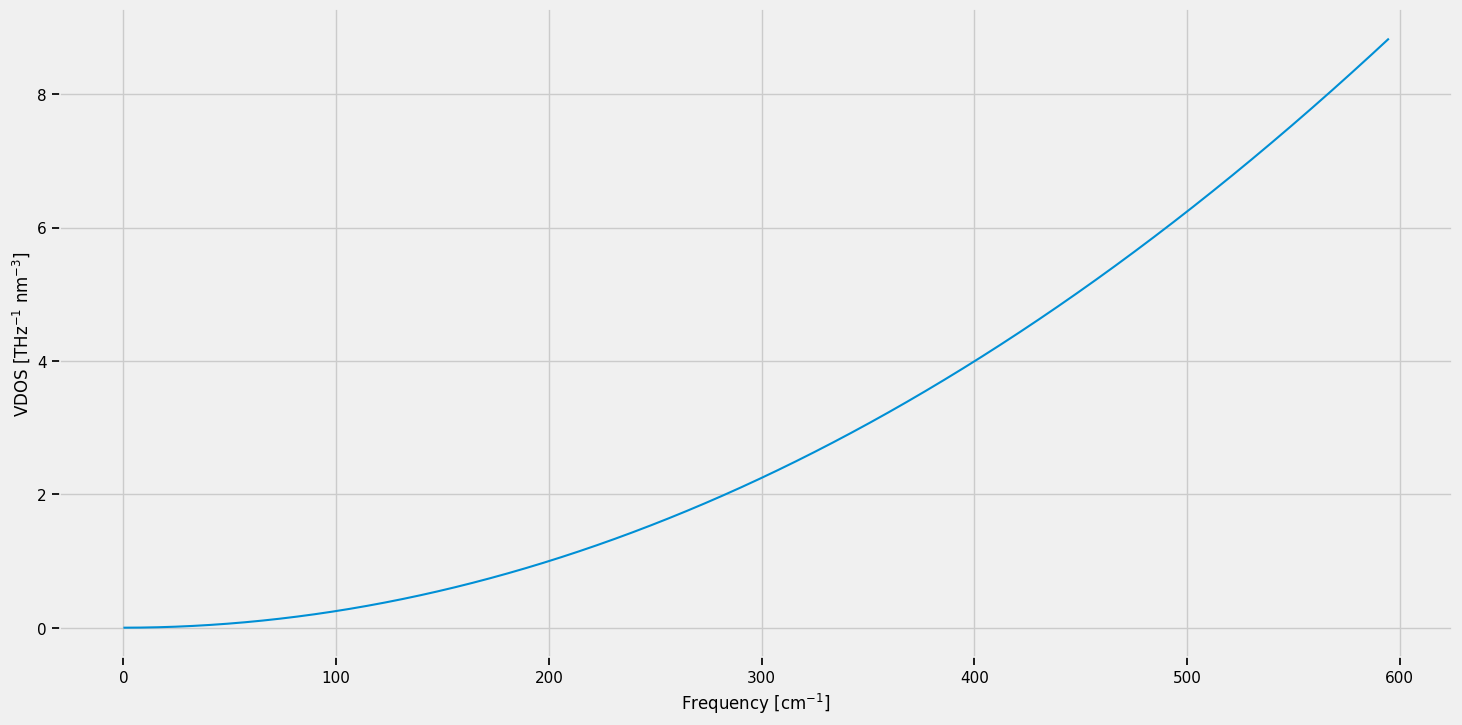

In [5]:
plt.figure(figsize=(16, 8))

plt.plot(array_frequency/(2*np.pi) * THzToCm, debye_density_of_states*1e3)

# plt.xlim([0, 400])

plt.xlabel(r"Frequency [cm$^{-1}$]")
plt.ylabel(r"VDOS [THz$^{-1}$ nm$^{-3}$]")

plt.show()

In [6]:
# confirm the integral is compatible with the 3*number density
(debye_density_of_states*(array_frequency[1] - array_frequency[0])).sum()

np.float64(0.3300495066008251)

In [7]:
3*number_density

0.33

In [8]:
# Exercise: How does the density of states change when density is reduced to 0.1, but keeping c the same, 
# compare with previous density of states

sound_speed = 60 # in A THz
number_density = 0.10 # in 1/A^3
frequency_cutoff = np.power(6 * np.pi**2 * number_density, 1/3) * sound_speed # in THz (angular)
array_frequency_01 = np.linspace(0, frequency_cutoff, 10000) # in THz (angular)

debye_density_of_states_01 = np.square(array_frequency_01) * 3 /(2 * np.pi**2 * np.power(sound_speed, 3)) # in THz^-1 A^-3

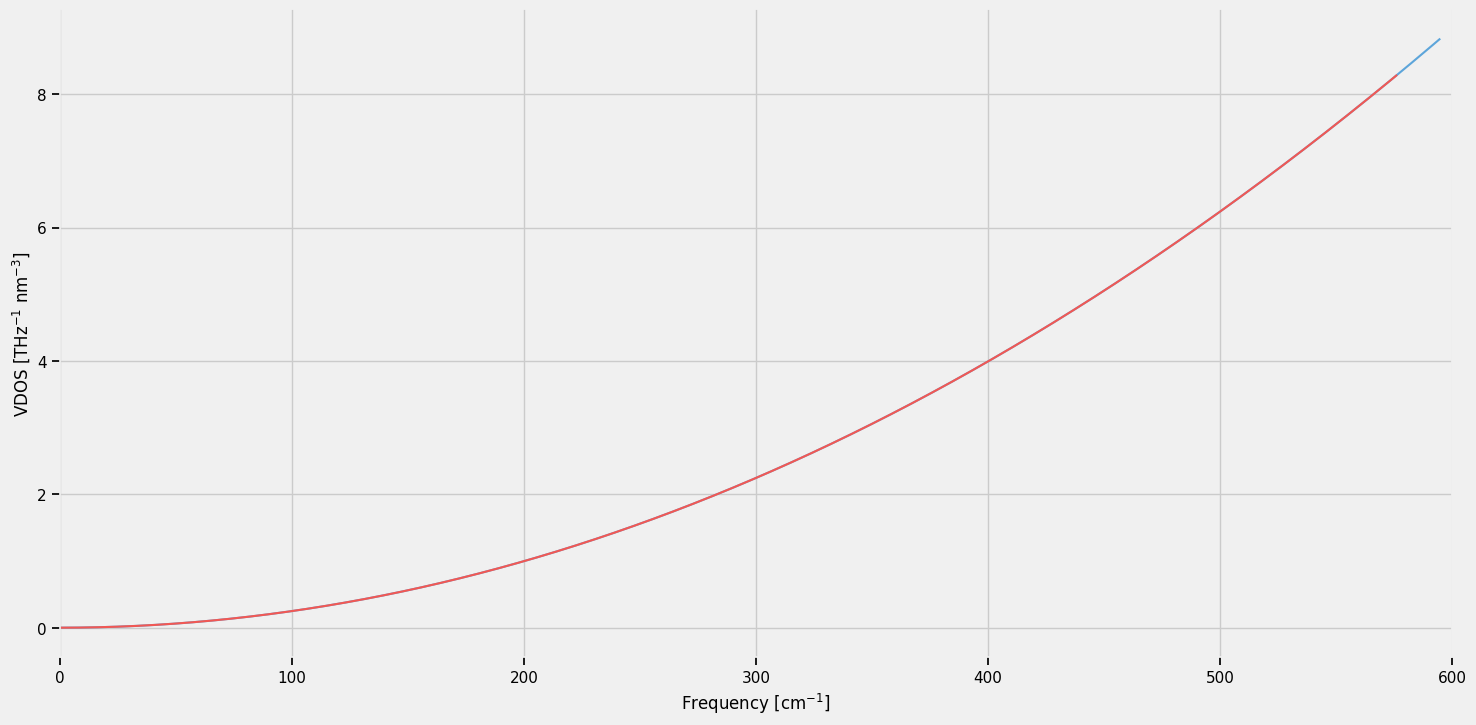

In [9]:
plt.figure(figsize=(16, 8))

plt.plot(array_frequency/(2*np.pi) * THzToCm, debye_density_of_states*1e3, color=Colors[3])
plt.plot(array_frequency_01/(2*np.pi) * THzToCm, debye_density_of_states_01*1e3, color=Colors[0])

plt.xlabel(r"Frequency [cm$^{-1}$]")
plt.ylabel(r"VDOS [THz$^{-1}$ nm$^{-3}$]")

plt.xlim([0, 600])

plt.show()

The only difference is at high frequency, the have a different total cutoff, density of states with lower real space density has a lower cutoff

We can show the Debye VDOS is "self similar"; i.e., we can obtain the Debye density of states for different densities either by controlling the cutoff or by applying transformation:
$$a = (\rho_1 / \rho_2)^{1/3}$$
$$g^{DR}(\omega) = \rho_1 / \rho_2  * g(\omega/a) \frac{1}{a}$$

Proof for Debye density of states ($\omega \ge 0$):

$$g^{DR}(\omega) = \rho_1 / \rho_2  * g(\omega/a) \frac{1}{a} = \rho_1 / \rho_2  * \frac{3}{2 \pi^2 c^3} \frac{\omega^2}{a^2} \frac{1}{a} H(\omega_{\rm cutoff} - \omega / a) = \frac{3}{2 \pi^2 c^3} \omega^2 H(a\omega_{\rm cutoff} - \omega)= g(\omega) |_{\text{cutoff =} a \omega_{\rm cutoff}}$$

The upper cutoff is shifted by a factor of $a$ as seen within the Heaviside step function ($H$), exactly as expected from the dependence of Debye cutoff frequency on the density

## Phonon spectral functions

From simple harmonic motion, we know that if a mode is damped, its frequency resonance will be broadened. Within quantum mechanics we have a similar principle, namely the Heisenberg's uncertainty principle, stating that finite time processes will have uncertain energy spectrum.

For phonons, this notion is formalized through language of phonon spectral functions. Below we explore what is the dependence of the Lorentzian spectral function on the broadening. In Perturbatively Disordered Crystal, the VDOS is a sum of such spectral functions, and hence the broadening of spectral functions will translate to smoothness of the VDOS.

In [10]:
from smooth_disorder.disorder_linewidth import lorentzian_numpy

x = np.linspace(-20, 20, 1000)

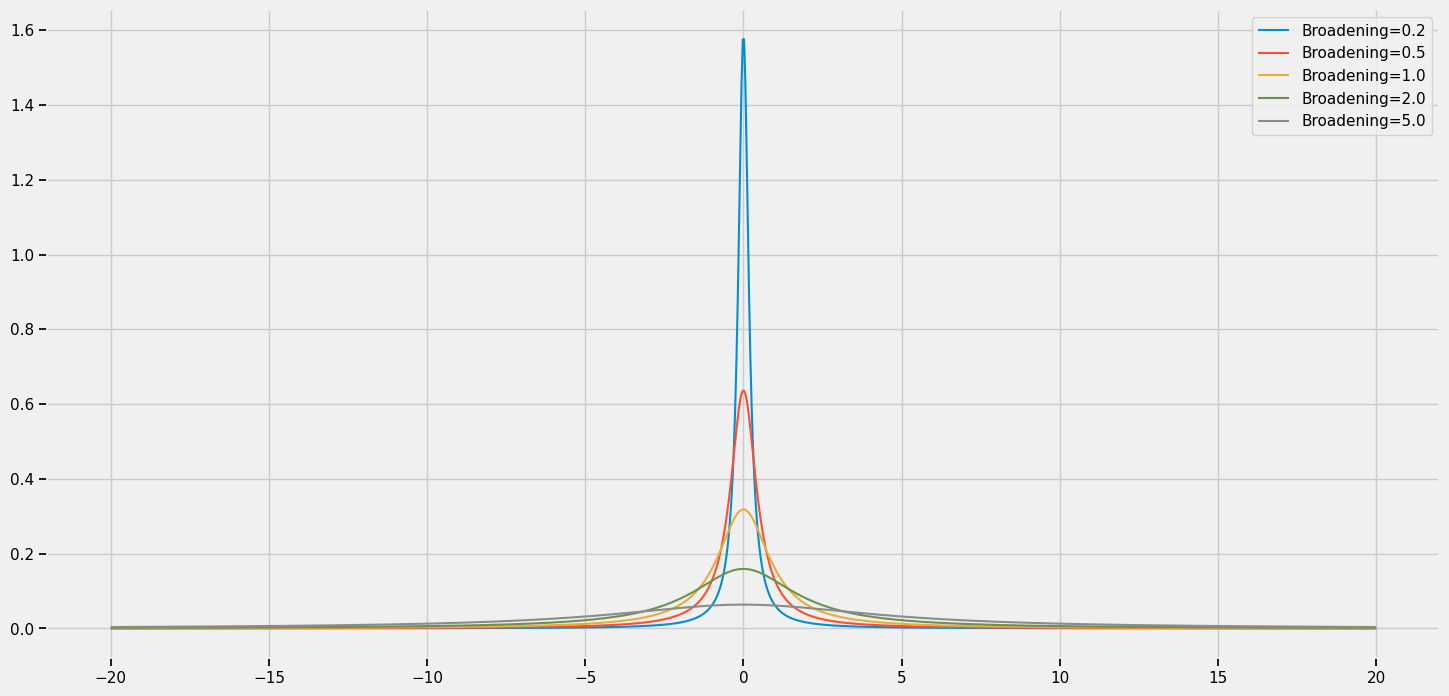

In [11]:
plt.figure(figsize=(16, 8))

for broadening in [0.2, 0.5, 1.0, 2.0, 5.0]:
    plt.plot(x, lorentzian_numpy(x, broadening), label=f"Broadening={broadening}")

plt.legend(loc='upper right')

plt.show()


Lorentzian spectral functions become more broadened as a function of HWHM. Since they conserve area, the height of the peak decreases with increased HWHM

We will see in notebook 5 how we can interpret the broadening of the VDOS in irradiated graphite in terms of broadening of spectral functions in crystal graphite, an idea called Pertubatively Disordered Crystal. This will allow us to extract disorder linewidth, propagation velocity and mean free path in irradiated graphite.
